In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from path import PathFinder
sns.set(style="whitegrid")

In [3]:
PATHS = PathFinder()
DIR_OUT = PATHS["DIR_SRC"] / "out" 
df_s1 = pd.read_csv(DIR_OUT / "study1.csv")
df_s2 = pd.read_csv(DIR_OUT / "study2.csv")

Successfully loaded /Users/niche/Library/CloudStorage/SynologyDrive-Cloud/03_papers/COLO/.env
Available project environments: 
    DIR_SRC=/Users/niche/Library/CloudStorage/SynologyDrive-Cloud/03_papers/COLO
    DIR_DATA=/Users/niche/Library/CloudStorage/SynologyDrive-Data/cow-colo
    LIB_PYNICHE=/Users/niche/Library/CloudStorage/SynologyDrive-Cloud/04_software/pyniche
    DIR_TMP=/


In [4]:
DICT_PARAMS = dict({
    "rtdetr-l": 45,
    "rtdetr-x": 86,
    "yolo12n": 2.6,
    "yolo12m": 20.2,
    "yolo12x": 59.1,
    "yolo11n": 2.6,
    "yolo11m": 20.1,
    "yolo11x": 56.9,
})
def add_params(df):
    df.loc[:, "params"] = df["model"].map(DICT_PARAMS)
    return df

def add_family(df):
    df.loc[:, ["family"]] = "DETR"
    df.loc[df["model"].str.contains("yolo12"), "family"] = "YOLOv12"
    df.loc[df["model"].str.contains("yolo11"), "family"] = "YOLOv11"
    return df

def add_size(df):
    df.loc[:, ["size"]] = "small"
    df.loc[df["model"].str.contains("yolo11x"), "size"] = "large"
    df.loc[df["model"].str.contains("yolo12x"), "size"] = "large"
    df.loc[df["model"].str.contains("rtdetr-x"), "size"] = "large"
    return df

def add_info(df):
    df = add_family(df)
    df = add_size(df)
    df = add_params(df)
    return df

In [17]:
df_s1.loc[:, ["family", "n", "data", "map5095", "map50", "precision", "recall"]].\
    groupby(["family", "n", "data",]).\
        aggregate({"map5095": ["mean", "std"], 
                   "map50": ["mean", "std"],
                   "precision": ["mean", "std"],
                   "recall": ["mean", "std"]
                    }).reset_index().\
            sort_values(["family", "n", "data"], ascending=[True, True, True]).\
                to_csv(DIR_OUT / "study1_pivot.csv", index=False)
add_size(df_s1).loc[:, ["data", "n", "family", "size", "map5095", "map50", "precision", "recall"]].\
    groupby(["family", "n", "data", "size"]).\
        aggregate({"map5095": ["mean", "std"], 
                   "map50": ["mean", "std"],
                   "precision": ["mean", "std"],
                   "recall": ["mean", "std"]
                   }).reset_index().\
            sort_values(["family", "n", "data", "size"], ascending=[True, True, True, True]).\
                to_csv(DIR_OUT / "study2_pivot.csv", index=False)

In [19]:
df_s2.loc[:, ["family", "n", "data", "size", "pretrain", "map5095", "map50", "precision", "recall"]].\
    groupby(["family", "n", "data", "size", "pretrain"]).\
        aggregate({"map5095": ["mean", "std"], 
                   "map50": ["mean", "std"],
                   "precision": ["mean", "std"],
                   "recall": ["mean", "std"],}).reset_index().\
            sort_values(["family", "n", "data", "size", "pretrain"], ascending=[True, True, True, True, True]).\
                to_csv(DIR_OUT / "study3_pivot.csv", index=False)

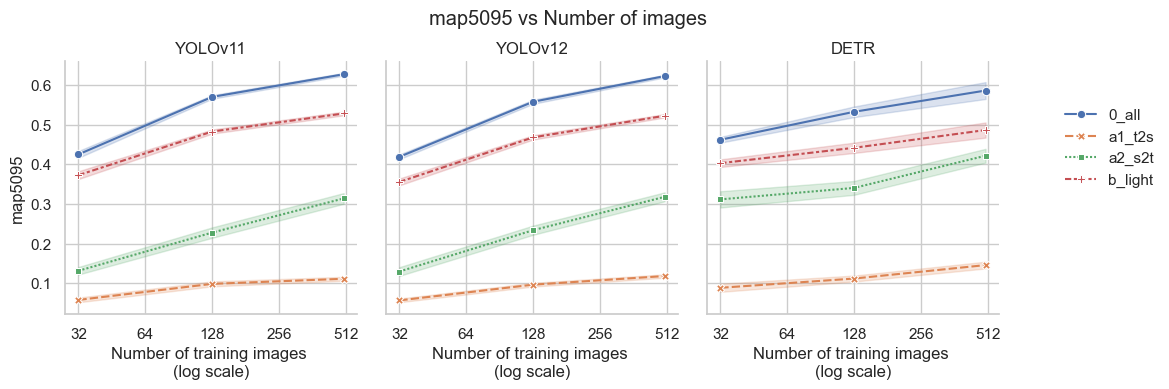

In [7]:
config_s1 = ["0_all", "a1_t2s", "a2_s2t", "b_light"]
sns.set(style="whitegrid")

def plot_s1_overview(df, metric):
    g = sns.FacetGrid(df, 
        col="family", col_order=["YOLOv11", "YOLOv12", "DETR"],
        sharey="row",margin_titles=True, 
        # height=6, aspect=1.2
        )
    g.map_dataframe(sns.lineplot, 
        x="n", y=metric, hue="data", style="data",
        err_style="band", errorbar=("se", 2),
        markers=True,)
    g.set(
        xscale="log",
        xticks=[2**i for i in range(5, 10)],
        xticklabels=[2**i for i in range(5, 10)],
        xlabel="Number of training images \n(log scale)",)
    # set bbox to relative x, y to axis
    g.add_legend(bbox_to_anchor=(1, .5), loc='lower right')
    g.set_titles(col_template="{col_name}")
    g.figure.set_size_inches(12, 4)
    # set 10% space above the plot, 20% space between rows, and 10% space between columns
    g.figure.subplots_adjust(top=0.85, hspace=0.2, wspace=0.1)
    g.fig.suptitle(f"{metric} vs Number of images")
    return g

g = plot_s1_overview(df_s1, "map5095")
# save
g.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_s1_overview.png", dpi=300)

In [27]:
import scipy.stats as stats

col_config = []
col_family = []
col_n = []
col_normal = []
col_var = []
col_pval = []

config_s1 = ["0_all", "a1_t2s", "a2_s2t", "b_light"]
ls_family = ["YOLOv11", "YOLOv12", "DETR"]
ls_n = [32, 128, 500]
for c in config_s1:
    for f in ls_family:
        for n in ls_n:
            df_sub = df_s1.query(f"data == '{c}' and family == '{f}' and n == {n}")
            df_small = df_sub.query("size == 'small'")
            df_large = df_sub.query("size == 'large'")
            # test normality
            _, p_small = stats.shapiro(df_small["map5095"])
            _, p_large = stats.shapiro(df_large["map5095"])
            if p_small > 0.05 and p_large > 0.05:
                # test equal variance
                _, p_var = stats.levene(df_small["map5095"], df_large["map5095"])
                if p_var > 0.05:
                    # run t-test
                    t_stat, p_val = stats.ttest_ind(df_small["map5095"], df_large["map5095"], equal_var=True)
                    col_var.append("true")
                    col_normal.append("true")
                else:
                    # run Welch's t-test
                    t_stat, p_val = stats.ttest_ind(df_small["map5095"], df_large["map5095"], equal_var=False)
                    col_var.append("false")
                    col_normal.append("true")
            else:
                # run Mann-Whitney U test
                u_stat, p_val = stats.mannwhitneyu(df_small["map5095"], df_large["map5095"])
                col_var.append("N/A")
                col_normal.append("false")
            col_config.append(c)
            col_family.append(f)
            col_n.append(n)
            if p_val < 0.001:
                col_pval.append("***")
            elif p_val < 0.01:
                col_pval.append("**")
            elif p_val < 0.05:
                col_pval.append("*")
            else:
                col_pval.append("ns")    
        
df_s1_test = pd.DataFrame({
    "config": col_config,
    "family": col_family,
    "n": col_n,
    "pval": col_pval,
    "normal": col_normal,
    "var": col_var,
})
df_s1_test.to_csv(DIR_OUT / "study1_stats.csv", index=False)   

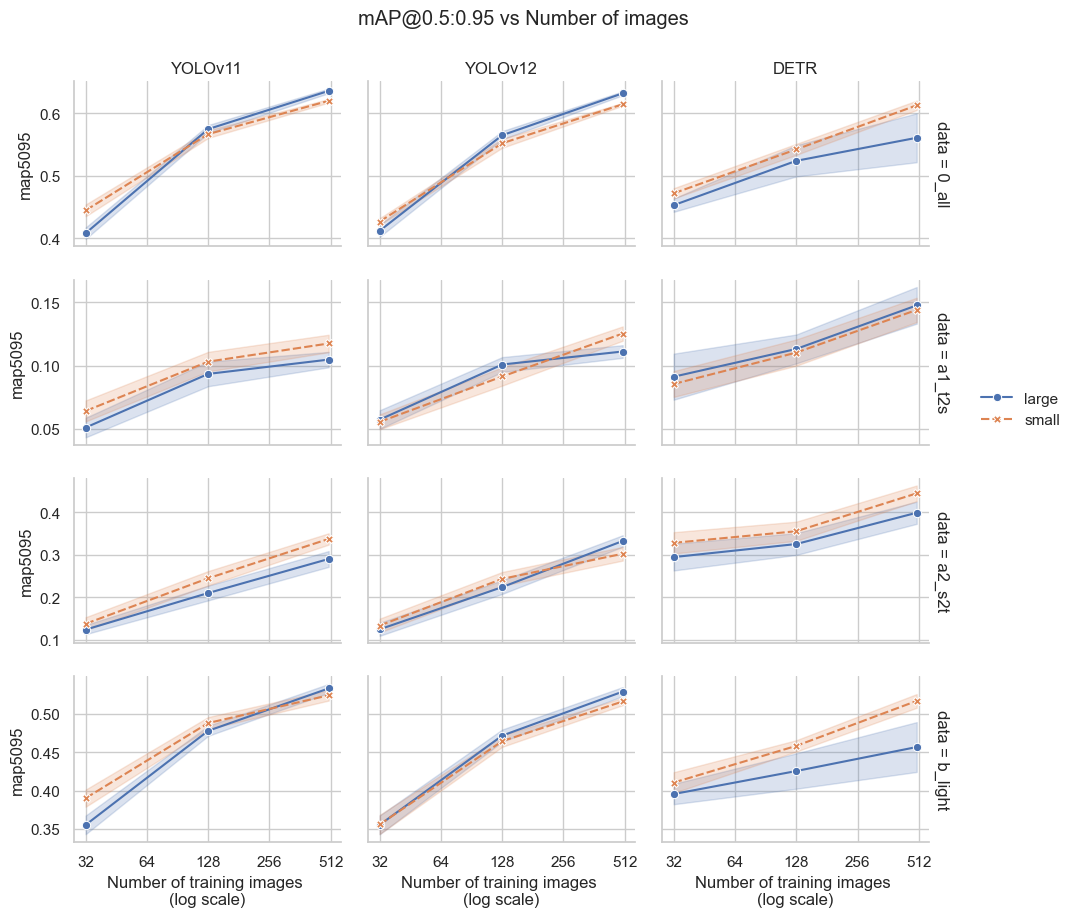

In [11]:
config_s1 = ["0_all", "a1_t2s", "a2_s2t", "b_light"]
sns.set(style="whitegrid")
g = sns.FacetGrid(df_s1, 
    col="family", col_order=["YOLOv11", "YOLOv12", "DETR"],
    row="data", row_order=config_s1, sharey="row",
    margin_titles=True)
g.map_dataframe(sns.lineplot, 
    x="n", y="map5095", hue="size", style="size",
    hue_order=["large", "small"],
    style_order=["large", "small"],
    err_style="band", errorbar=("se", 2),
    markers=True,
    )
g.set(
    xscale="log",
    xticks=[2**i for i in range(5, 10)],
    xticklabels=[2**i for i in range(5, 10)],
    xlabel="Number of training images \n(log scale)",)

g.add_legend(bbox_to_anchor=(1, 0.5), loc='lower right')
g.set_titles(col_template="{col_name}")
g.figure.set_size_inches(11, 9)
g.figure.subplots_adjust(top=0.9, hspace=0.2, wspace=0.1)
g.fig.suptitle("mAP@0.5:0.95 vs Number of images")
g.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_s1_by_models.png", dpi=300)

In [26]:
import scipy.stats as stats

col_config = []
col_family = []
col_size = []
col_n = []
col_normal = []
col_var = []
col_pval = []

config_ext = ["e_IMU", "e_VT"]
ls_family = ["YOLOv11", "YOLOv12", "DETR"]
ls_n = [16, 64, 200]
for c in config_ext:
    for f in ls_family:
        for size in ["small", "large"]:
            for n in ls_n:
                df_sub = df_s2.query(f"data == '{c}' and family == '{f}' and n == {n} and size == '{size}'")
                df_pretrain = df_sub.query("pretrain == True")
                df_no_pretrain = df_sub.query("pretrain == False")
              
                # test normality
                _, p_small = stats.shapiro(df_pretrain["map5095"])
                _, p_large = stats.shapiro(df_no_pretrain["map5095"])
                if p_small > 0.05 and p_large > 0.05:
                    # test equal variance
                    _, p_var = stats.levene(df_pretrain["map5095"], df_no_pretrain["map5095"])
                    if p_var > 0.05:
                        # run t-test
                        t_stat, p_val = stats.ttest_ind(df_pretrain["map5095"], df_no_pretrain["map5095"], equal_var=True)
                        col_var.append("true")
                        col_normal.append("true")
                    else:
                        # run Welch's t-test
                        t_stat, p_val = stats.ttest_ind(df_pretrain["map5095"], df_no_pretrain["map5095"], equal_var=False)
                        col_var.append("false")
                        col_normal.append("true")
                else:
                    # run Mann-Whitney U test
                    u_stat, p_val = stats.mannwhitneyu(df_pretrain["map5095"], df_no_pretrain["map5095"])
                    col_var.append("N/A")
                    col_normal.append("false")
                col_config.append(c)
                col_family.append(f)
                col_size.append(size)
                col_n.append(n)
                if p_val < 0.001:
                    col_pval.append("***")
                elif p_val < 0.01:
                    col_pval.append("**")
                elif p_val < 0.05:
                    col_pval.append("*")
                else:
                    col_pval.append("ns")
        
df_s2_test = pd.DataFrame({
    "config": col_config,
    "family": col_family,
    "size": col_size,
    "n": col_n,
    "pval": col_pval,
    "normal": col_normal,
    "var": col_var,
})
df_s2_test.to_csv(DIR_OUT / "study2_stats.csv", index=False)                    

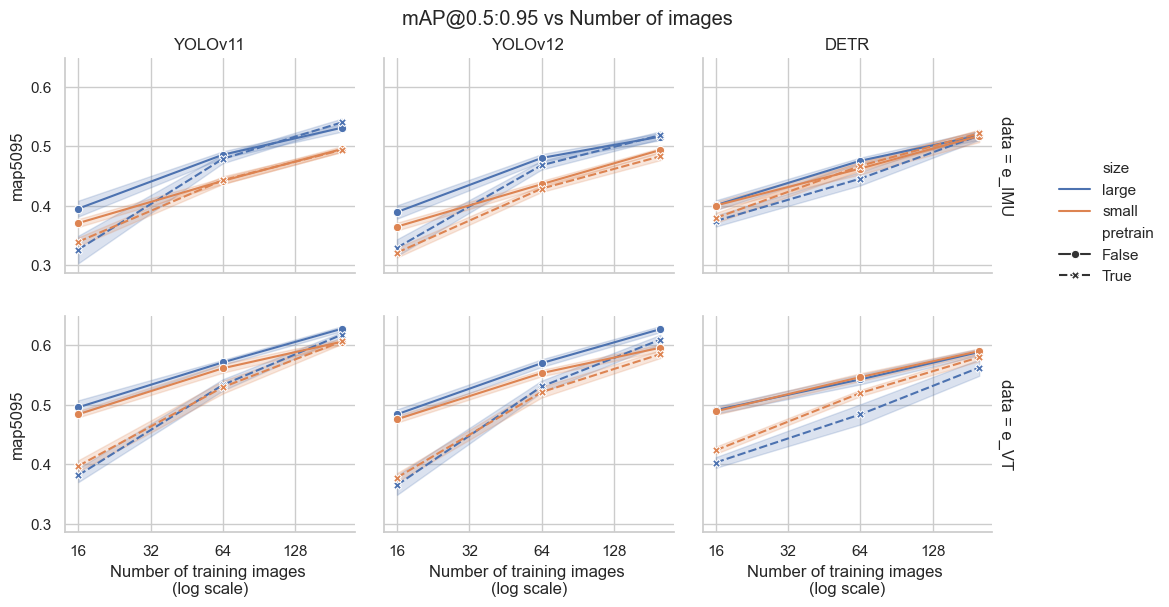

In [28]:
# facet by model
config_ext = ["e_IMU", "e_VT"]

g = sns.FacetGrid(df_s2, 
    row="data", col="family",
    col_order=["YOLOv11", "YOLOv12", "DETR"],
    margin_titles=True)
g.map_dataframe(sns.lineplot, 
    x="n", y="map5095", hue="size", style="pretrain",
    hue_order=["large", "small"],
     # style_order=["True", "False"],
    err_style="band", errorbar=("se", 2),
    markers=True,
    )
# x-axis: 32, 64, 128, 256, 500, in log scale
g.set(
    xscale="log",
    xticks=[2**i for i in range(4, 8)],
    xticklabels=[2**i for i in range(4, 8)],
    xlabel="Number of training images \n(log scale)",)
g.add_legend(bbox_to_anchor=(1, 0.5), loc='lower right')
g.set_titles(col_template="{col_name}")
g.figure.set_size_inches(12, 6)
g.figure.subplots_adjust(top=0.9, hspace=0.2, wspace=0.1)
g.fig.suptitle("mAP@0.5:0.95 vs Number of images")
g.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_s2_overview.png", dpi=300)

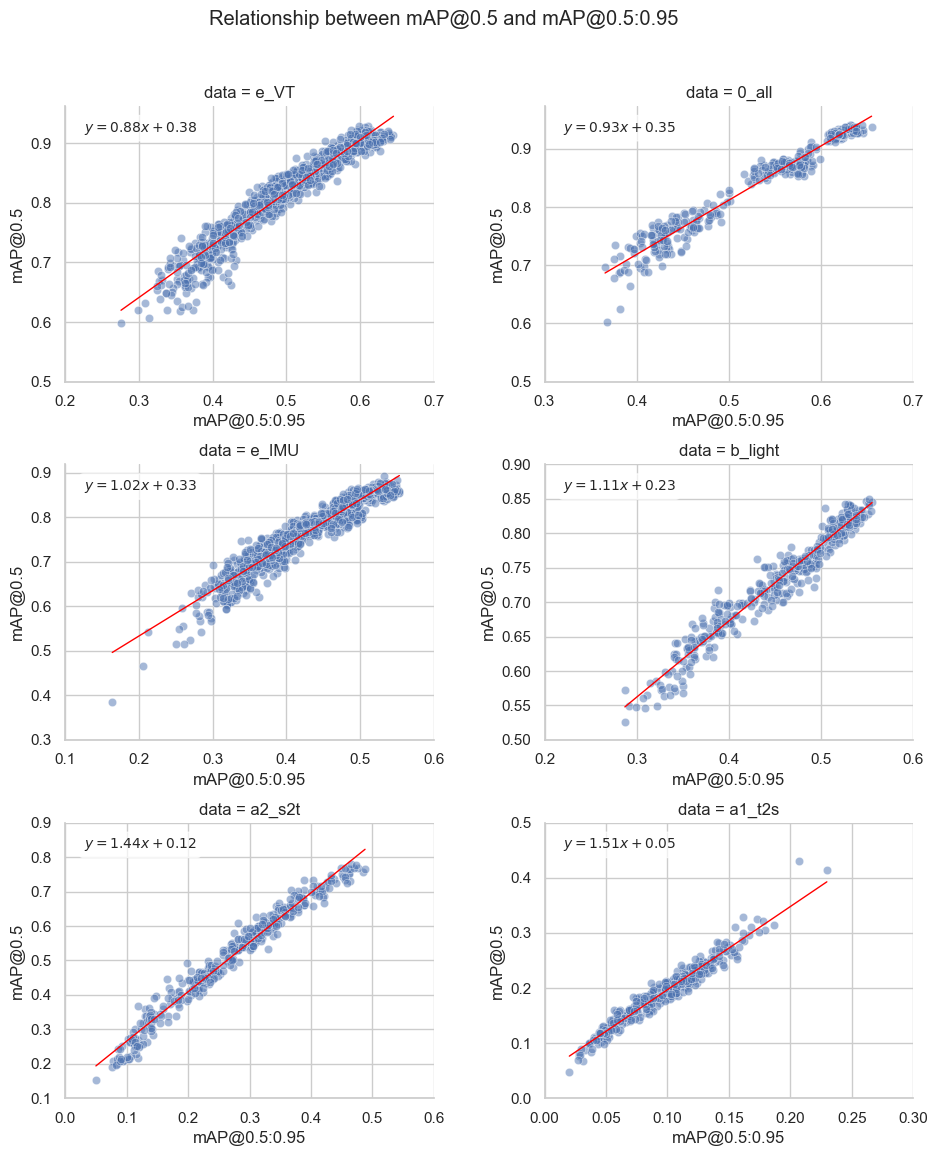

In [5]:
# merge data, family, size, map50, map5095
cols = ["data", "family", "size", "map50", "map5095", "precision", "recall"]
df_merge = pd.concat(
    [df_s1.loc[:, cols], 
     df_s2.loc[:, cols]],
)
# scatter plot
# hue: data
sns.set(style="whitegrid")
# wrap_col by data
g = sns.FacetGrid(df_merge, 
    sharey=False, sharex=False,
    col="data", col_wrap=2,
    col_order=["e_VT", "0_all",
               "e_IMU", "b_light", 
               "a2_s2t", "a1_t2s"],
    margin_titles=True
)
# Map the scatterplot first (with hue)
g.map_dataframe(
    sns.scatterplot,
    x="map5095", y="map50",
    alpha=0.5,
    zorder=1,
)

# For each subplot: fit a line, draw it behind dots, and annotate
for ax, (data_key, sub_data) in zip(g.axes.flat, g.facet_data()):
    # Fit line
    x = sub_data["map5095"]
    y = sub_data["map50"]
    if len(x) < 2:  # skip if not enough points
        continue
    slope, intercept = np.polyfit(x, y, deg=1)

    # Create line data for plotting
    x_vals = np.linspace(x.min(), x.max(), 100)
    y_vals = slope * x_vals + intercept

    # Plot the line behind the dots
    ax.plot(x_vals, y_vals, 
            lw=1,
            color="red", zorder=1)  # lower zorder puts line behind

    # Add equation text
    eqn = f"$y = {slope:.2f}x + {intercept:.2f}$"
    ax.text(
        0.05, 0.95, eqn,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
    )

    # Custom ticks at 0.1 intervals
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    x_rg_min = np.max([0, np.floor(x_min * 10) / 10])
    x_rg_max = np.min([1, np.ceil(x_max * 10) / 10 + 0.1])
    y_rg_min = np.max([0, np.floor(y_min * 10) / 10])
    y_rg_max = np.min([1, np.ceil(y_max * 10) / 10 + 0.1])
    ax.set_xticks(np.arange(x_rg_min, x_rg_max, 0.1))
    ax.set_yticks(np.arange(y_rg_min, y_rg_max, 0.1))
    ax.grid(True)

# Set labels
g.set(
    xscale="linear",
    yscale="linear",
    xlabel="mAP@0.5:0.95",
    ylabel="mAP@0.5",
)
g.figure.set_size_inches(10, 12)
g.figure.subplots_adjust(top=0.9, hspace=0.3, wspace=0.3)
g.fig.suptitle("Relationship between mAP@0.5 and mAP@0.5:0.95")

g.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_metrics.png", dpi=300)

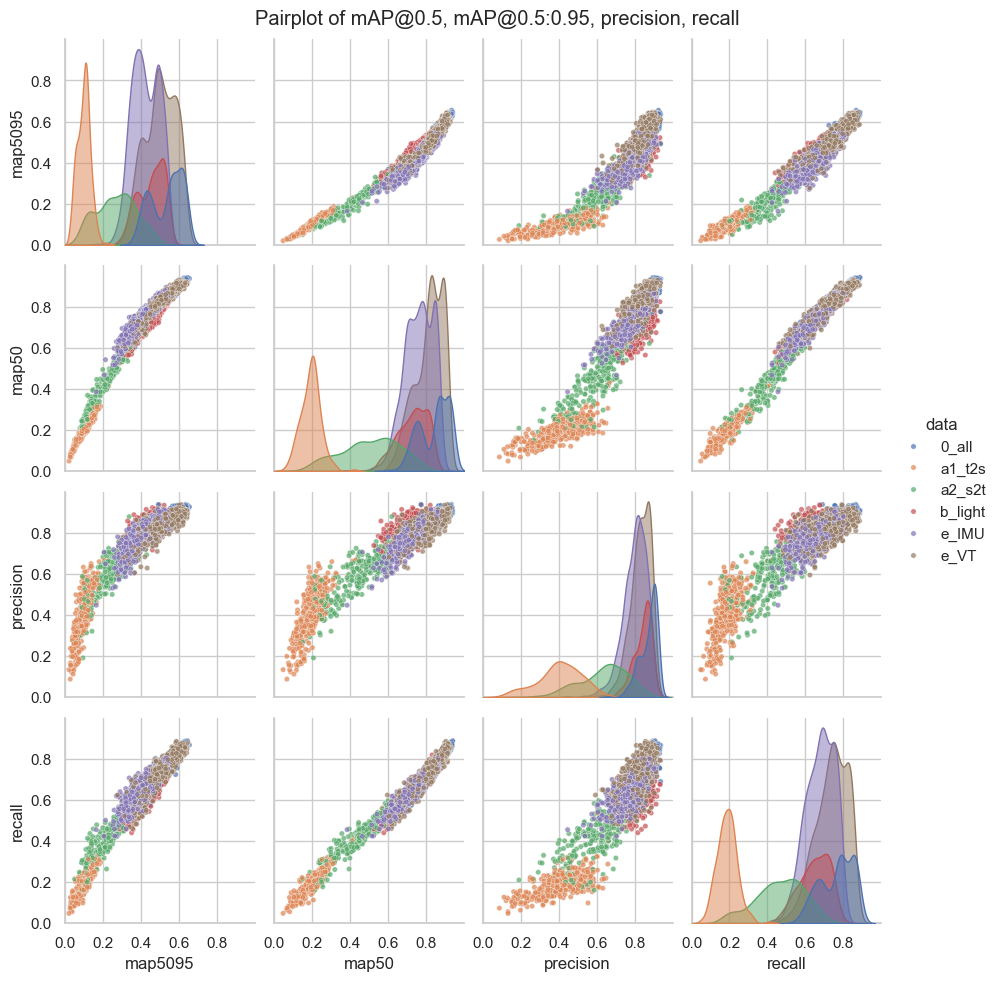

In [43]:
cols = ["data", "family", "size", "map50", "map5095", "precision", "recall"]
df_merge = pd.concat(
    [df_s1.loc[:, cols], 
     df_s2.loc[:, cols]],
)
# seaborn scatter plot (map5095, precision, recall) pairplot
g = sns.pairplot(df_merge, 
    hue="data", 
    vars=["map5095", "map50","precision", "recall"],
    diag_kind="kde",
    # palette=sns.color_palette("husl", 6),
    height=2.5,
    # dot size
    plot_kws={"s": 15, "alpha": 0.7},
    diag_kws={"fill": True, "alpha": 0.5},
)
# set axis tick labels to 0.2 intervals in range [0, 1]
for ax in g.axes.flatten():
    ax.set_xticks(np.arange(0, 1, 0.2))
    ax.set_yticks(np.arange(0, 1, 0.2))
    # set limits to 0, 1
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True)

g.figure.set_size_inches(10, 10)
g.figure.subplots_adjust(top=.95, hspace=0.1, wspace=0.1)
g.fig.suptitle("Pairplot of mAP@0.5, mAP@0.5:0.95, precision, recall")
# save
g.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_metrics.png", dpi=300)

In [16]:
df_merge.query("data == '0_all'").groupby(["family"]).aggregate({
    "map50": ["mean", "std"],
    "map5095": ["mean", "std"],
    "precision": ["mean", "std"],
    "recall": ["mean", "std"]
})

map50             map5095           precision              recall  \
             mean       std      mean       std      mean       std      mean   
family                                                                          
DETR     0.838553  0.071200  0.527231  0.069840  0.873721  0.045232  0.765380   
YOLOv11  0.844149  0.083501  0.539261  0.088274  0.874263  0.048903  0.758727   
YOLOv12  0.845722  0.080006  0.533481  0.086950  0.869463  0.045939  0.764699   

                   
              std  
family             
DETR     0.073244  
YOLOv11  0.093712  
YOLOv12  0.091268

### Training time

min_mu: 0.6019008159637451


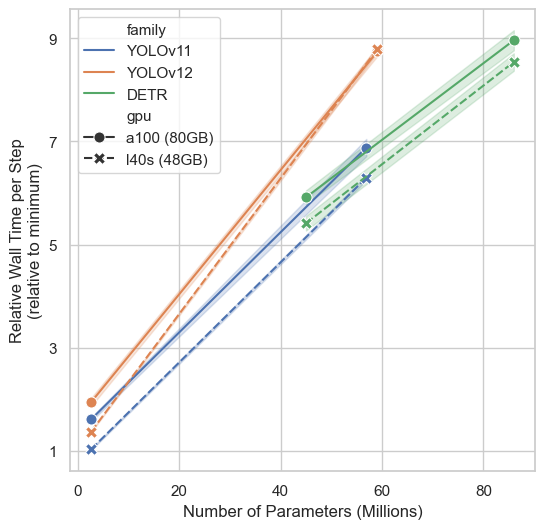

In [ ]:
df_time = pd.read_csv(DIR_OUT / "train_time.csv")

min_mu = df_time["median"].min(); print(f"min_mu: {min_mu}")
df_time["median_x"] = df_time["median"] / min_mu

sns.set(style="whitegrid")
plt.figure(figsize=(6, 6))
sns.lineplot(data=df_time, x="params", y="median_x", 
             hue="family", style="gpu",
             hue_order=["YOLOv11", "YOLOv12", "DETR"],
             err_style="band", errorbar=("se", 2),
             markers=True, markersize=8,
             )
plt.yticks(np.arange(1, 10, 2))
plt.xticks(np.arange(0, 100, 20))
plt.ylabel("Relative Wall Time per Step\n(relative to minimum)")
plt.xlabel("Number of Parameters (Millions)")
# move legend to the right
# plt.legend(title="Family", loc="upper left", bbox_to_anchor=(1, 1))
plt.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_time_train.png", dpi=300)

In [25]:
df_infer = pd.read_csv(DIR_OUT / "infer.csv", header=None)
df_infer.columns = ["model", "fps", "gpu"]
df_infer = add_info(df_infer)
map_gpu = dict({
    "L40S": "l40s (48GB)",
    "A100": "a100 (80GB)",
    "3080ti": "3080ti (12GB)",
    "4090": "4090 (24GB)",
})
df_infer.loc[:, "gpu"] = df_infer["gpu"].map(map_gpu)
df_infer = df_infer.loc[:, ["model", "gpu", "fps"]].\
    groupby(["model", "gpu"]).\
        aggregate({"fps": ["mean", "std"]}).reset_index()
df_infer.columns = ["model", "gpu", "fps_mean", "fps_std"]
df_infer["fps_mean"] = df_infer["fps_mean"].round(2)
df_infer["fps_std"] = df_infer["fps_std"].round(2)
df_infer

,model,gpu,fps_mean,fps_std
0,rtdetr-l,3080ti (12GB),116.14,0.13
1,rtdetr-l,4090 (24GB),206.96,1.62
2,rtdetr-l,a100 (80GB),210.14,0.43
3,rtdetr-l,l40s (48GB),168.98,0.06
4,rtdetr-x,3080ti (12GB),70.38,0.40
5,rtdetr-x,4090 (24GB),132.64,0.53
6,rtdetr-x,a100 (80GB),136.31,17.64
7,rtdetr-x,l40s (48GB),111.68,0.44
8,yolo11n,3080ti (12GB),1030.26,67.80
9,yolo11n,4090 (24GB),2079.76,86.72


In [24]:
df_time = pd.read_csv(DIR_OUT / "train_time.csv")

min_mu = df_time["median"].min(); print(f"min_mu: {min_mu}")
df_time["median_x"] = df_time["median"] / min_mu
df_time = df_time.loc[:, ["model", "family", "size", "gpu", "params", "median", "median_x"]].\
    groupby(["model", "family", "size", "gpu", "params"]).\
        aggregate({"median": ["mean", "std"],
                   "median_x": ["mean", "std", "size"],
                   }).reset_index()
df_time.columns = ["model", "family", "size", "gpu", "params", 
                   "train_mu", "train_std", "train_mu_x", "train_std_x", "n"]
df_time["train_mu"] = df_time["train_mu"].round(2)
df_time["train_std"] = df_time["train_std"].round(2)
df_time["train_mu_x"] = df_time["train_mu_x"].round(2)
df_time["train_std_x"] = df_time["train_std_x"].round(2)
df_time_all = pd.merge(df_time, df_infer, on=["model", "gpu"], how="outer")
df_time_all.to_csv(DIR_OUT / "time_info.csv", index=False)

min_mu: 0.6019008159637451


### Inference time

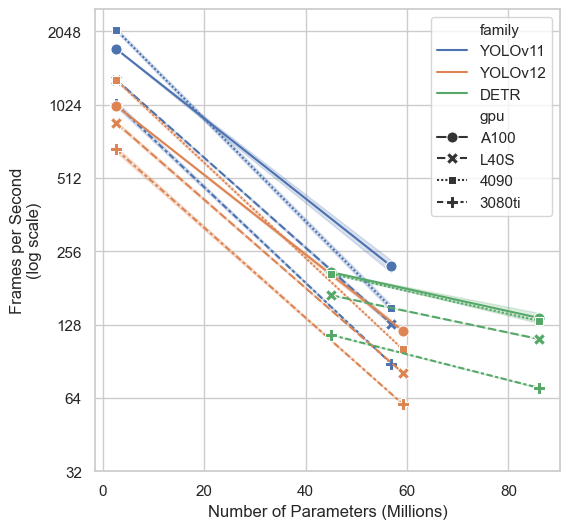

In [91]:
df_infer = pd.read_csv(DIR_OUT / "infer.csv", header=None)
df_infer.columns = ["model", "fps", "gpu"]
df_infer = add_info(df_infer)
plt.figure(figsize=(6, 6))
g = sns.lineplot(data=df_infer, x="params", y="fps",
             hue="family", style="gpu",
             hue_order=["YOLOv11", "YOLOv12", "DETR"],
             style_order=["A100", "L40S", "4090", "3080ti"],
             err_style="band", errorbar=("se", 2),
             markers=True, markersize=8,)
g.set(
    yscale="log",
    yticks=[2**i for i in range(5, 12)],
    yticklabels=[2**i for i in range(5, 12)],
    )

plt.ylabel("Frames per Second\n(log scale)")
plt.xlabel("Number of Parameters (Millions)")
plt.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_time_infer.png", dpi=300)


<Figure size 700x600 with 0 Axes>

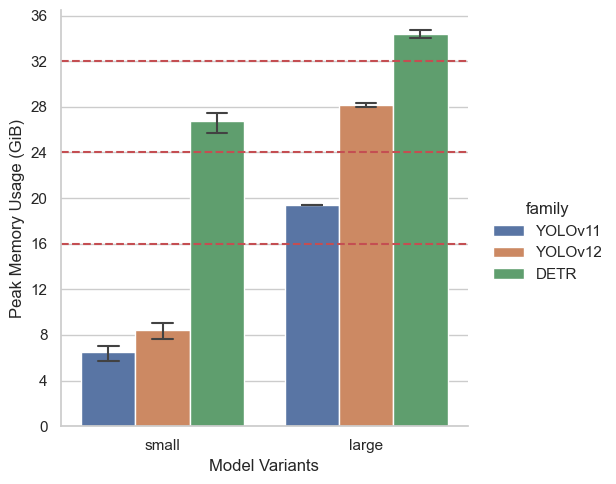

In [14]:
df_ram = pd.read_csv(DIR_OUT / "train_mem.csv")

sns.set(style="whitegrid")
plt.figure(figsize=(7, 6))

df_ram["size"] = df_ram["size"].astype("category")
df_ram["size"] = df_ram["size"].cat.reorder_categories(["small", "large"])
g = sns.catplot(
    data=df_ram.query("n == 500"), x="size", y="mem",     
    kind="bar",
    hue="family", 
    hue_order=["YOLOv11", "YOLOv12", "DETR"],
    capsize=.3, err_kws={"linewidth": 1.5},
            )
# draw red line on 16, 24 and 32
g.map(plt.axhline, y=24, color="r", linestyle="--")
g.map(plt.axhline, y=32, color="r", linestyle="--")
g.map(plt.axhline, y=16, color="r", linestyle="--")
g.set(
    yticks=[4*i for i in range(10)],
    yticklabels=[4*i for i in range(10)],
    ylabel="Peak Memory Usage (GiB)",
    xlabel="Model Variants",
)

plt.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_ram_train.png", dpi=300)

<Figure size 700x600 with 0 Axes>

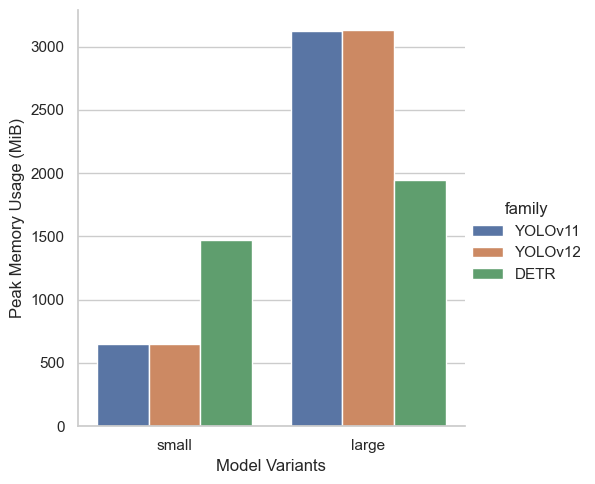

In [106]:
# batch = 64
# yolo11x:  8954.13MB
# yolo12x:  8962.41MB
# yolov11n: 1777.25MB
# yolov12n:  1777.16MB
# rtdetr-x:  6586.85MB
# rtdetr-l:  5057.37MP
# batch = 16
# yolo11x = 3125.37 MB
# yolo12x = 3133.62 mB
# yolo11n =  650.00 mB
# yolo12n =  648.75 mB
# rtdetr-x =  1948.73 mB
# rtdetr-l = 1469.92 mB
ls_models = ["yolo11n", "yolo12n", "yolo11x", "yolo12x", "rtdetr-l", "rtdetr-x"]
ls_mem = [650, 648.75, 3125.37, 3133.62, 1469.92, 1948.73]
df_ram_infer = pd.DataFrame({"model": ls_models, "mem": ls_mem})
df_ram_infer = add_info(df_ram_infer)
df_ram_infer["size"] = df_ram_infer["size"].astype("category")
df_ram_infer["size"] = df_ram_infer["size"].cat.reorder_categories(["small", "large"])
plt.figure(figsize=(7, 6))

g = sns.catplot(
    data=df_ram_infer, x="size", y="mem",     
    kind="bar",
    hue="family", 
    hue_order=["YOLOv11", "YOLOv12", "DETR"],
    capsize=.3, err_kws={"linewidth": 1.5},
            )
g.set(
    ylabel="Peak Memory Usage (MiB)",
    xlabel="Model Variants",
)
plt.savefig(PATHS["DIR_SRC"]/"ms"/"r1"/"src"/"fig_ram_infer.png", dpi=300)

In [107]:
df_ram_infer

,model,mem,family,size,params
0,yolo11n,650.00,YOLOv11,small,2.6
1,yolo12n,648.75,YOLOv12,small,2.6
2,yolo11x,3125.37,YOLOv11,large,56.9
3,yolo12x,3133.62,YOLOv12,large,59.1
4,rtdetr-l,1469.92,DETR,small,45.0
5,rtdetr-x,1948.73,DETR,large,86.0


In [110]:
df_ram = pd.read_csv(DIR_OUT / "train_mem.csv")
df_mem = df_ram.loc[:, ["model", "family", "size", "params", "n", "mem"]].\
    groupby(["model", "family", "size", "params"]).\
        aggregate({"mem": ["mean", "std"]}).reset_index()
df_mem.columns = ["model", "family", "size", "params", "train_mem_mu", "train_mem_std"]
df_mem.loc[:, "train_mem_mu"] = df_mem["train_mem_mu"].round(2)
df_mem.loc[:, "train_mem_std"] = df_mem["train_mem_std"].round(2)
df_mem = pd.merge(df_mem, df_ram_infer.loc[:, ["model", "mem"]], on=["model"], how="outer")
df_mem.columns = ["model", "family", "size", "params", "train_mem_mu", "train_mem_std", "infer_mem"]
df_mem.loc[:, "infer_mem"] = df_mem["infer_mem"].round(2)
df_mem.to_csv(DIR_OUT / "mem_info.csv", index=False)

In [27]:
df_mem = pd.read_csv(DIR_OUT / "mem_info.csv")
df_time = pd.read_csv(DIR_OUT / "time_info.csv")
df_mem

,model,family,size,params,train_mem_mu,train_mem_std,infer_mem
0,rtdetr-l,DETR,small,45.0,24.46,2.46,1469.92
1,rtdetr-x,DETR,large,86.0,31.60,3.18,1948.73
2,yolo11n,YOLOv11,small,2.6,5.92,1.08,650.00
3,yolo11x,YOLOv11,large,56.9,18.08,1.00,3125.37
4,yolo12n,YOLOv12,small,2.6,7.67,1.21,648.75
5,yolo12x,YOLOv12,large,59.1,26.89,1.07,3133.62


In [ ]:
df_time.loc[:, ["model", "gpu", "train_mu", "train_std", "fps_mean", "fps_std"]]

,model,gpu,train_mu,train_std,fps_mean,fps_std
0,rtdetr-l,3080ti (12GB),NaN,NaN,116.14,0.13
1,rtdetr-l,4090 (24GB),NaN,NaN,206.96,1.62
2,rtdetr-l,a100 (80GB),3.56,0.09,210.14,0.43
3,rtdetr-l,l40s (48GB),3.26,0.10,168.98,0.06
4,rtdetr-x,3080ti (12GB),NaN,NaN,70.38,0.40
5,rtdetr-x,4090 (24GB),NaN,NaN,132.64,0.53
6,rtdetr-x,a100 (80GB),5.39,0.13,136.31,17.64
7,rtdetr-x,l40s (48GB),5.14,0.11,111.68,0.44
8,yolo11n,3080ti (12GB),NaN,NaN,1030.26,67.80
9,yolo11n,4090 (24GB),NaN,NaN,2079.76,86.72


In [42]:
# to wide (train_mu (3080ti), train_mu (4090), train_mu (L40S), train_mu (A100))
df_time_w = df_time.loc[:, ["model", "gpu", "train_mu", "train_std", "fps_mean", "fps_std"]].\
    pivot(index=["model"], columns="gpu", 
        values=["train_mu", "train_std", "fps_mean", "fps_std"])
df_time_w.to_csv(DIR_OUT / "time_info_wide.csv", index=True)